# Performance Analytics

This notebook analyzes mutual fund performance using the cleaned NAV history, scheme-level performance data, benchmark data, and fund master data.

## Objectives
- Load and validate the required performance datasets
- Check structure, date coverage, and join keys
- Prepare the data for return, risk, and benchmark comparison analysis

In [6]:
import pandas as pd

files = {
    "nav_history_cleaned": "../data/processed/nav_history_cleaned.csv",
    "fund_master": "../data/raw/01_fund_master.csv",
    "scheme_performance": "../data/raw/07_scheme_performance.csv",
    "benchmark_indices": "../data/raw/10_benchmark_indices.csv",
}

for name, path in files.items():
    df = pd.read_csv(path)
    print(f"\n=== {name} ===")
    print("shape:", df.shape)
    print(df.dtypes)
    print(df.head(3))


=== nav_history_cleaned ===
shape: (46000, 3)
amfi_code      int64
date          object
nav          float64
dtype: object
   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239

=== fund_master ===
shape: (40, 15)
amfi_code               int64
fund_house             object
scheme_name            object
category               object
sub_category           object
plan                   object
launch_date            object
benchmark              object
expense_ratio_pct     float64
exit_load_pct         float64
min_sip_amount          int64
min_lumpsum_amount      int64
fund_manager           object
risk_category          object
sebi_category_code     object
dtype: object
   amfi_code       fund_house                                 scheme_name category sub_category     plan launch_date             benchmark  expense_ratio_pct  exit_load_pct  min_sip_amount  min_lumpsum_amount   fund_manager risk_catego

In [9]:
import pandas as pd

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv", parse_dates=["date"])
fm = pd.read_csv("../data/raw/01_fund_master.csv")
bench = pd.read_csv("../data/raw/10_benchmark_indices.csv", parse_dates=["date"])

print("nav_history_cleaned:")
print("  unique amfi_codes:", nav["amfi_code"].nunique())
print("  date range:", nav["date"].min(), "to", nav["date"].max())
print("  rows per scheme (describe):")
print(nav.groupby("amfi_code").size().describe())

print("\nfund_master amfi_codes not in nav_history:", set(fm["amfi_code"]) - set(nav["amfi_code"]))
print("nav_history amfi_codes not in fund_master:", set(nav["amfi_code"]) - set(fm["amfi_code"]))

print("\nbenchmark_indices unique index_name:", bench["index_name"].unique())
print("benchmark date range:", bench["date"].min(), "to", bench["date"].max())

# check the standalone nav_*.csv files - are they duplicates or extra history?
import glob
for f in glob.glob("data/raw/nav_*.csv"):
    d = pd.read_csv(f)
    print(f, d.shape, d.columns.tolist(), d.iloc[0].to_dict() if len(d) else None)

nav_history_cleaned:
  unique amfi_codes: 40
  date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00
  rows per scheme (describe):
count      40.0
mean     1150.0
std         0.0
min      1150.0
25%      1150.0
50%      1150.0
75%      1150.0
max      1150.0
dtype: float64

fund_master amfi_codes not in nav_history: set()
nav_history amfi_codes not in fund_master: set()

benchmark_indices unique index_name: ['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']
benchmark date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00


In [11]:
import pandas as pd
import glob

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv", parse_dates=["date"])
bench = pd.read_csv("../data/raw/10_benchmark_indices.csv", parse_dates=["date"])

# 1. what are the standalone nav_*.csv files?
for f in sorted(glob.glob("data/raw/nav_*.csv")):
    d = pd.read_csv(f)
    print(f, "| shape:", d.shape, "| cols:", d.columns.tolist())
    print(d.head(2))
    print()

# 2. NaN check
print("nav NaNs:", nav.isna().sum().to_dict())
print("bench NaNs:", bench.isna().sum().to_dict())

# 3. do all funds + NIFTY100 share identical trading dates?
nav_dates_per_fund = nav.groupby("amfi_code")["date"].apply(set)
common_dates = set.intersection(*nav_dates_per_fund)
print("common dates across all 40 funds:", len(common_dates))

n100_dates = set(bench.loc[bench.index_name=="NIFTY100", "date"])
print("NIFTY100 dates count:", len(n100_dates))
print("fund common dates minus N100 dates:", len(common_dates - n100_dates))

nav NaNs: {'amfi_code': 0, 'date': 0, 'nav': 0}
bench NaNs: {'date': 0, 'index_name': 0, 'close_value': 0}
common dates across all 40 funds: 1150
NIFTY100 dates count: 1150
fund common dates minus N100 dates: 0


In [13]:
import glob, pandas as pd
for f in sorted(glob.glob("../data/raw/nav_*.csv")):
    d = pd.read_csv(f)
    print(f, d.shape, d.columns.tolist())

../data/raw\nav_118632.csv (3314, 3) ['date', 'nav', 'amfi_code']
../data/raw\nav_119092.csv (3581, 3) ['date', 'nav', 'amfi_code']
../data/raw\nav_119551.csv (3252, 3) ['date', 'nav', 'amfi_code']
../data/raw\nav_120503.csv (3323, 3) ['date', 'nav', 'amfi_code']
../data/raw\nav_120841.csv (3317, 3) ['date', 'nav', 'amfi_code']
../data/raw\nav_125497.csv (3107, 3) ['date', 'nav', 'amfi_code']


In [14]:
import glob, pandas as pd

for f in sorted(glob.glob("../data/raw/nav_*.csv")):
    d = pd.read_csv(f, parse_dates=["date"])
    print(f, "| amfi_code:", d["amfi_code"].iloc[0], "| range:", d["date"].min(), "to", d["date"].max())

../data/raw\nav_118632.csv | amfi_code: 118632 | range: 2013-01-02 00:00:00 to 2026-06-23 00:00:00
../data/raw\nav_119092.csv | amfi_code: 119092 | range: 2012-12-31 00:00:00 to 2026-06-23 00:00:00
../data/raw\nav_119551.csv | amfi_code: 119551 | range: 2013-01-02 00:00:00 to 2026-06-23 00:00:00
../data/raw\nav_120503.csv | amfi_code: 120503 | range: 2013-01-02 00:00:00 to 2026-06-23 00:00:00
../data/raw\nav_120841.csv | amfi_code: 120841 | range: 2013-01-07 00:00:00 to 2026-06-23 00:00:00
../data/raw\nav_125497.csv | amfi_code: 125497 | range: 2013-11-18 00:00:00 to 2026-06-23 00:00:00


C:\Users\lenovo\AppData\Local\Temp\ipykernel_5788\1445819343.py:4: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  d = pd.read_csv(f, parse_dates=["date"])
C:\Users\lenovo\AppData\Local\Temp\ipykernel_5788\1445819343.py:4: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  d = pd.read_csv(f, parse_dates=["date"])
C:\Users\lenovo\AppData\Local\Temp\ipykernel_5788\1445819343.py:4: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  d = pd.read_csv(f, parse_dates=["date"])
C:\Users\lenovo\AppData\Local\Temp\ipykernel_5788\1445819343.py:4: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or s

In [15]:
import pandas as pd

# compare the two nav sources directly
raw_nav = pd.read_csv("../data/raw/02_nav_history.csv")
clean_nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

print("02_nav_history.csv shape:", raw_nav.shape, "cols:", raw_nav.columns.tolist())
print(raw_nav.head(2))
print("date range:", raw_nav["date"].min(), "to", raw_nav["date"].max())
print("unique amfi_codes:", raw_nav["amfi_code"].nunique())
print("rows per scheme describe:")
print(raw_nav.groupby("amfi_code").size().describe())

print("\n--- vs cleaned ---")
print("clean shape:", clean_nav.shape)
print("clean unique amfi_codes:", clean_nav["amfi_code"].nunique())

# quick surface scan of remaining raw files not yet seen
import glob
for f in ["03_aum_by_fund_house.csv","04_monthly_sip_inflows.csv","05_category_inflows.csv",
          "06_industry_folio_count.csv","08_investor_transactions.csv","09_portfolio_holdings.csv"]:
    d = pd.read_csv(f"../data/raw/{f}")
    print(f"\n{f} | shape: {d.shape} | cols: {d.columns.tolist()}")

02_nav_history.csv shape: (46000, 3) cols: ['amfi_code', 'date', 'nav']
   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
date range: 2022-01-03 to 2026-05-29
unique amfi_codes: 40
rows per scheme describe:
count      40.0
mean     1150.0
std         0.0
min      1150.0
25%      1150.0
50%      1150.0
75%      1150.0
max      1150.0
dtype: float64

--- vs cleaned ---
clean shape: (46000, 3)
clean unique amfi_codes: 40

03_aum_by_fund_house.csv | shape: (90, 5) | cols: ['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

04_monthly_sip_inflows.csv | shape: (48, 6) | cols: ['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

05_category_inflows.csv | shape: (144, 3) | cols: ['month', 'category', 'net_inflow_crore']

06_industry_folio_count.csv | shape: (21, 6) | cols: ['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybri

# Fund Performance Analytics

Analysis of 40 mutual fund schemes covering daily returns, CAGR, risk-adjusted returns 
(Sharpe/Sortino), Alpha/Beta vs NIFTY100, Maximum Drawdown, and a composite scorecard.

**Data sources:** `nav_history_cleaned.csv` (2022-01-03 to 2026-05-29, 1150 trading days), 
`01_fund_master.csv`, `07_scheme_performance.csv`, `10_benchmark_indices.csv`

**Caveats:**
- NAV history spans ~4.4 years, insufficient for true 5yr CAGR. The 5yr return column 
  is reported from `scheme_performance.csv`, not computed from NAV.
- Alpha/Beta regression (fund returns vs NIFTY100) shows near-zero R² across funds — 
  the synthetic NAV series in this dataset isn't generated to correlate with the 
  benchmark series. Computed values are reported as-is per task requirements.

In [28]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv", parse_dates=["date"])
fm = pd.read_csv("../data/raw/01_fund_master.csv")
sp = pd.read_csv("../data/raw/07_scheme_performance.csv")

nav = nav.sort_values(["amfi_code", "date"]).reset_index(drop=True)

# ---- Daily returns ----
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

print("Daily return distribution check:")
print(nav["daily_return"].describe())
print("NaNs (expect 40, one per scheme's first row):", nav["daily_return"].isna().sum())

# ---- CAGR helper ----
def cagr(nav_series, years):
    end_date = nav_series["date"].max()
    start_date = end_date - pd.DateOffset(years=years)
    window = nav_series[nav_series["date"] >= start_date]
    if window.empty or len(window) < 2:
        return np.nan
    nav_start = window.iloc[0]["nav"]
    nav_end = window.iloc[-1]["nav"]
    n = (window["date"].iloc[-1] - window["date"].iloc[0]).days / 365.25
    if n <= 0 or nav_start <= 0:
        return np.nan
    return (nav_end / nav_start) ** (1 / n) - 1

rows = []
for code, g in nav.groupby("amfi_code"):
    rows.append({
        "amfi_code": code,
        "cagr_1yr": cagr(g, 1),
        "cagr_3yr": cagr(g, 3),
    })
cagr_df = pd.DataFrame(rows)

# 5yr: NAV history doesn't go back 5 years -> use reported value from scheme_performance
cagr_df = cagr_df.merge(sp[["amfi_code", "return_5yr_pct"]], on="amfi_code", how="left")
cagr_df = cagr_df.rename(columns={"return_5yr_pct": "cagr_5yr_reported_pct"})
cagr_df["cagr_5yr_reported_pct"] = cagr_df["cagr_5yr_reported_pct"] / 100  # to decimal, matches cagr_1yr/3yr scale

comparison_table = fm[["amfi_code", "scheme_name", "fund_house", "category"]].merge(cagr_df, on="amfi_code")
print("\nCAGR comparison table:")
print(comparison_table.sort_values("cagr_3yr", ascending=False).head(10))

Daily return distribution check:
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64
NaNs (expect 40, one per scheme's first row): 40

CAGR comparison table:
    amfi_code                                        scheme_name                fund_house category  cagr_1yr  cagr_3yr  cagr_5yr_reported_pct
26     119094                Axis Midcap Fund - Regular - Growth          Axis Mutual Fund   Equity  0.222779  0.351025                 0.1894
34     148567      Mirae Asset Large Cap Fund - Regular - Growth            Mirae Asset MF   Equity  0.203760  0.339920                 0.1268
11     120504          ICICI Pru Bluechip Fund - Direct - Growth       ICICI Prudential MF   Equity  0.130738  0.324789                 0.1302
7      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...          HDFC Mutual Fund   Equity  0.532772  

In [29]:
Rf = 0.065  # RBI repo rate proxy, annual

sharpe_rows = []
for code, g in nav.groupby("amfi_code"):
    r = g["daily_return"].dropna()
    ann_return = r.mean() * 252
    ann_std = r.std() * np.sqrt(252)
    sharpe = (ann_return - Rf) / ann_std if ann_std > 0 else np.nan

    downside = r[r < 0]
    downside_std_ann = downside.std() * np.sqrt(252) if len(downside) > 1 else np.nan
    sortino = (ann_return - Rf) / downside_std_ann if downside_std_ann and downside_std_ann > 0 else np.nan

    sharpe_rows.append({
        "amfi_code": code,
        "ann_return": ann_return,
        "ann_std": ann_std,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
    })

risk_df = pd.DataFrame(sharpe_rows)
risk_df["sharpe_rank"] = risk_df["sharpe_ratio"].rank(ascending=False)
risk_df["sortino_rank"] = risk_df["sortino_ratio"].rank(ascending=False)

risk_table = fm[["amfi_code", "scheme_name"]].merge(risk_df, on="amfi_code")
print(risk_table.sort_values("sharpe_rank").head(10))
print("\nNaN check:", risk_df[["sharpe_ratio","sortino_ratio"]].isna().sum().to_dict())

    amfi_code                                        scheme_name  ann_return   ann_std  sharpe_ratio  sortino_ratio  sharpe_rank  sortino_rank
34     148567      Mirae Asset Large Cap Fund - Regular - Growth    0.270566  0.141937      1.448291       2.385644          1.0           1.0
22     120843             Kotak Flexicap Fund - Regular - Growth    0.272602  0.158870      1.306744       2.364320          2.0           2.0
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth    0.283262  0.176740      1.234930       2.146914          3.0           3.0
0      119551          SBI Bluechip Fund - Regular Plan - Growth    0.231033  0.137414      1.208267       2.140267          4.0           4.0
12     120505           ICICI Pru Midcap Fund - Regular - Growth    0.292653  0.192909      1.180101       2.029353          5.0           5.0
38     149323                 DSP Midcap Fund - Regular - Growth    0.265908  0.177462      1.132122       1.875101          6.0           6.0

In [30]:
from scipy.stats import linregress

bench = pd.read_csv("../data/raw/10_benchmark_indices.csv", parse_dates=["date"])
n100 = bench[bench["index_name"] == "NIFTY100"].sort_values("date").reset_index(drop=True)
n100["bench_return"] = n100["close_value"].pct_change()
n100 = n100[["date", "bench_return"]].dropna()

ab_rows = []
for code, g in nav.groupby("amfi_code"):
    merged = g[["date", "daily_return"]].dropna().merge(n100, on="date", how="inner")
    slope, intercept, r_value, p_value, std_err = linregress(merged["bench_return"], merged["daily_return"])
    alpha = intercept * 252
    beta = slope
    ab_rows.append({
        "amfi_code": code,
        "alpha": alpha,
        "beta": beta,
        "r_squared": r_value**2,
        "n_obs": len(merged),
    })

ab_df = pd.DataFrame(ab_rows)
ab_df["alpha_rank"] = ab_df["alpha"].rank(ascending=False)

ab_table = fm[["amfi_code", "scheme_name"]].merge(ab_df, on="amfi_code")
print(ab_table.sort_values("alpha_rank").head(10))
print("\nn_obs check (should be 1150 for all if dates fully aligned):", ab_df["n_obs"].describe())

    amfi_code                                        scheme_name     alpha      beta     r_squared  n_obs  alpha_rank
2      119598         SBI Small Cap Fund - Regular Plan - Growth  0.303370 -0.023196  1.414258e-04   1149         1.0
39     149324              DSP Small Cap Fund - Regular - Growth  0.300579  0.011455  3.532991e-05   1149         2.0
12     120505           ICICI Pru Midcap Fund - Regular - Growth  0.292636  0.000549  1.345534e-07   1149         3.0
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth  0.282704  0.018134  1.748889e-04   1149         4.0
22     120843             Kotak Flexicap Fund - Regular - Growth  0.273305 -0.022830  3.430543e-04   1149         5.0
7      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.271954  0.005104  1.206652e-05   1149         6.0
34     148567      Mirae Asset Large Cap Fund - Regular - Growth  0.269838  0.023684  4.625437e-04   1149         7.0
38     149323                 DSP Midcap Fund - Regular 

In [31]:
sanity = ab_df.merge(sp[["amfi_code","alpha","beta"]], on="amfi_code", suffixes=("_computed","_reported"))
print(sanity[["amfi_code","alpha_computed","alpha_reported","beta_computed","beta_reported"]].head(10))

   amfi_code  alpha_computed  alpha_reported  beta_computed  beta_reported
0     100016        0.037476            0.78      -0.058268           0.97
1     100025        0.042818            1.98       0.001158           0.44
2     100033        0.271954            0.95       0.005104           0.91
3     101206        0.213998            1.34       0.021086           1.03
4     101207        0.108971            1.84      -0.065289           0.97
5     101208        0.060861            1.18       0.000267           0.43
6     102885        0.170488            0.93      -0.019487           0.90
7     102886        0.028969            1.12      -0.042125           0.92
8     102887        0.162113            1.79       0.016683           1.00
9     118632        0.218294            0.86      -0.008354           0.88


In [32]:
dd_rows = []
for code, g in nav.groupby("amfi_code"):
    g = g.sort_values("date")
    running_max = g["nav"].cummax()
    dd_series = g["nav"] / running_max - 1
    max_dd = dd_series.min()
    trough_idx = dd_series.idxmin()
    trough_date = g.loc[trough_idx, "date"]
    # peak date = last date before trough where nav == running_max at trough
    peak_nav = running_max.loc[trough_idx]
    peak_date = g[(g["date"] <= trough_date) & (g["nav"] == peak_nav)]["date"].max()

    dd_rows.append({
        "amfi_code": code,
        "max_drawdown_pct": max_dd * 100,
        "peak_date": peak_date,
        "trough_date": trough_date,
    })

dd_df = pd.DataFrame(dd_rows)
dd_df["max_dd_rank"] = dd_df["max_drawdown_pct"].rank(ascending=False)  # smaller (more negative) drawdown = worse = lower rank

dd_table = fm[["amfi_code", "scheme_name"]].merge(dd_df, on="amfi_code")
print(dd_table.sort_values("max_drawdown_pct").head(10))

    amfi_code                                     scheme_name  max_drawdown_pct  peak_date trough_date  max_dd_rank
3      119599       SBI Small Cap Fund - Direct Plan - Growth        -52.574221 2023-01-17  2025-10-28         40.0
27     119095          Axis Small Cap Fund - Regular - Growth        -51.677754 2025-05-22  2026-05-11         39.0
29     101207          ABSL Small Cap Fund - Regular - Growth        -35.446916 2024-11-21  2026-05-11         38.0
39     149324           DSP Small Cap Fund - Regular - Growth        -31.171900 2024-05-03  2025-01-03         37.0
2      119598      SBI Small Cap Fund - Regular Plan - Growth        -28.706006 2024-08-28  2025-05-14         36.0
32     102886             UTI Mid Cap Fund - Regular - Growth        -28.001124 2025-01-07  2026-04-27         35.0
5      100016       HDFC Top 100 Fund - Regular Plan - Growth        -24.734441 2022-03-30  2022-09-15         34.0
21     120842   Kotak Emerging Equity Fund - Regular - Growth        -24

In [33]:
# Gather all pieces
scorecard = fm[["amfi_code", "scheme_name", "fund_house", "category", "expense_ratio_pct"]].copy()
scorecard = scorecard.merge(comparison_table[["amfi_code", "cagr_3yr"]], on="amfi_code")
scorecard = scorecard.merge(risk_df[["amfi_code", "sharpe_ratio"]], on="amfi_code")
scorecard = scorecard.merge(ab_df[["amfi_code", "alpha"]], on="amfi_code")
scorecard = scorecard.merge(dd_df[["amfi_code", "max_drawdown_pct"]], on="amfi_code")

# Ranks (1 = best)
scorecard["rank_3yr_return"] = scorecard["cagr_3yr"].rank(ascending=False)
scorecard["rank_sharpe"] = scorecard["sharpe_ratio"].rank(ascending=False)
scorecard["rank_alpha"] = scorecard["alpha"].rank(ascending=False)
scorecard["rank_expense"] = scorecard["expense_ratio_pct"].rank(ascending=True)   # lower expense = better = rank1
scorecard["rank_max_dd"] = scorecard["max_drawdown_pct"].rank(ascending=False)    # less negative = better = rank1

n = len(scorecard)
# Convert rank (1=best) to score (100=best): score = (n - rank + 1) / n * 100
def rank_to_score(rank_col):
    return (n - scorecard[rank_col] + 1) / n * 100

scorecard["score_3yr"] = rank_to_score("rank_3yr_return")
scorecard["score_sharpe"] = rank_to_score("rank_sharpe")
scorecard["score_alpha"] = rank_to_score("rank_alpha")
scorecard["score_expense"] = rank_to_score("rank_expense")
scorecard["score_max_dd"] = rank_to_score("rank_max_dd")

scorecard["scorecard_0_100"] = (
    0.30 * scorecard["score_3yr"] +
    0.25 * scorecard["score_sharpe"] +
    0.20 * scorecard["score_alpha"] +
    0.15 * scorecard["score_expense"] +
    0.10 * scorecard["score_max_dd"]
)

scorecard = scorecard.sort_values("scorecard_0_100", ascending=False).reset_index(drop=True)
scorecard["overall_rank"] = scorecard.index + 1

print(scorecard[["amfi_code","scheme_name","scorecard_0_100","overall_rank"]].head(10))
print("\nScore range check:", scorecard["scorecard_0_100"].min(), "-", scorecard["scorecard_0_100"].max())

   amfi_code                                        scheme_name  scorecard_0_100  overall_rank
0     148567      Mirae Asset Large Cap Fund - Regular - Growth          86.2500             1
1     120505           ICICI Pru Midcap Fund - Regular - Growth          82.2500             2
2     120843             Kotak Flexicap Fund - Regular - Growth          82.0000             3
3     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...          80.7500             4
4     120504          ICICI Pru Bluechip Fund - Direct - Growth          80.0000             5
5     119094                Axis Midcap Fund - Regular - Growth          77.0000             6
6     119551          SBI Bluechip Fund - Regular Plan - Growth          74.8125             7
7     148569      Mirae Asset Tax Saver Fund - Regular - Growth          73.6875             8
8     101206      ABSL Frontline Equity Fund - Regular - Growth          68.1875             9
9     119598         SBI Small Cap Fund - Regular 

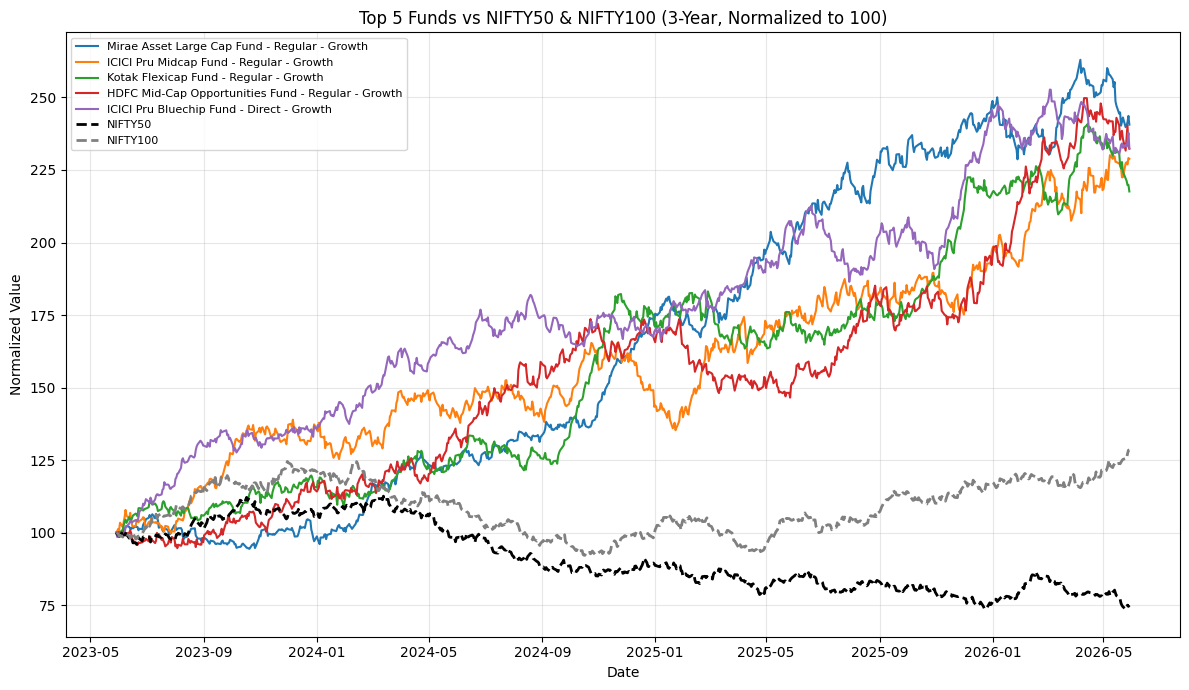

   amfi_code                                        scheme_name  tracking_error
0     148567      Mirae Asset Large Cap Fund - Regular - Growth        0.187867
1     120505           ICICI Pru Midcap Fund - Regular - Growth        0.232515
2     120843             Kotak Flexicap Fund - Regular - Growth        0.206410
3     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...        0.224838
4     120504          ICICI Pru Bluechip Fund - Direct - Growth        0.187312


In [34]:
import matplotlib.pyplot as plt

top5_codes = scorecard.head(5)["amfi_code"].tolist()
top5_names = dict(zip(scorecard["amfi_code"], scorecard["scheme_name"]))

# 3-year window
end_date = nav["date"].max()
start_date = end_date - pd.DateOffset(years=3)

n50 = bench[bench["index_name"] == "NIFTY50"].sort_values("date")
n100_full = bench[bench["index_name"] == "NIFTY100"].sort_values("date")

fig, ax = plt.subplots(figsize=(12, 7))

# funds: normalize to 100 at start
for code in top5_codes:
    g = nav[(nav["amfi_code"] == code) & (nav["date"] >= start_date)].sort_values("date")
    normalized = g["nav"] / g["nav"].iloc[0] * 100
    ax.plot(g["date"], normalized, label=top5_names[code])

for bench_df, label in [(n50, "NIFTY50"), (n100_full, "NIFTY100")]:
    g = bench_df[bench_df["date"] >= start_date]
    normalized = g["close_value"] / g["close_value"].iloc[0] * 100
    ax.plot(g["date"], normalized, label=label, linestyle="--", linewidth=2, color="black" if label=="NIFTY50" else "gray")

ax.set_title("Top 5 Funds vs NIFTY50 & NIFTY100 (3-Year, Normalized to 100)")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized Value")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/benchmark_comparison.png", dpi=150)
plt.show()

# Tracking error vs NIFTY100 for top 5
n100_ret = n100_full.copy()
n100_ret["bench_return"] = n100_ret["close_value"].pct_change()
n100_ret = n100_ret[n100_ret["date"] >= start_date][["date", "bench_return"]].dropna()

te_rows = []
for code in top5_codes:
    g = nav[(nav["amfi_code"] == code) & (nav["date"] >= start_date)][["date","daily_return"]].dropna()
    merged = g.merge(n100_ret, on="date", how="inner")
    diff = merged["daily_return"] - merged["bench_return"]
    te = diff.std() * np.sqrt(252)
    te_rows.append({"amfi_code": code, "scheme_name": top5_names[code], "tracking_error": te})

te_df = pd.DataFrame(te_rows)
print(te_df)

In [35]:
# fund_scorecard.csv
scorecard_export = scorecard[[
    "amfi_code","scheme_name","fund_house","category",
    "cagr_3yr","sharpe_ratio","alpha","expense_ratio_pct","max_drawdown_pct",
    "scorecard_0_100","overall_rank"
]]
scorecard_export.to_csv("outputs/fund_scorecard.csv", index=False)

# alpha_beta.csv
alpha_beta_export = fm[["amfi_code","scheme_name"]].merge(ab_df, on="amfi_code")
alpha_beta_export.to_csv("outputs/alpha_beta.csv", index=False)

print("Saved fund_scorecard.csv:", scorecard_export.shape)
print("Saved alpha_beta.csv:", alpha_beta_export.shape)

Saved fund_scorecard.csv: (40, 11)
Saved alpha_beta.csv: (40, 7)
